# 06 - DTW on real machine data

Notebooks 01-05 run on the seeded synthetic dataset, where every variant differs from the
reference by exactly one known distortion. This notebook applies the same DTW
implementation to two real recordings, where nothing is controlled: the two runs have
different durations, different numbers of motion cycles, and their own noise.

**What we compare.** `data/mat-files/axis_data1.csv` and `axis_data2.csv` - the position
`q` of the rotary axis in two runs of the same machine, one value per line, already
decimated to 2 Hz (0.5 s per sample). Both runs sweep back and forth between +180 and
-180 degrees, but run 1 sweeps 6 times over 647 s while run 2 sweeps 8 times over 517 s.
Two series of a similar shape running at different speeds and different lengths.

In [9]:
import sys
from pathlib import Path

# The notebooks live in `notebooks/`, the packages in the project root.
ROOT = Path.cwd()
if not (ROOT / "data").is_dir():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from utils import plotting
from utils.distances import dtw_cost_matrix, dtw_path

%matplotlib inline

## Loading the recordings

Each CSV is a single column of `q` values in degrees, with no header and no time column.
The machine records at 1 kHz, which the from-scratch DP implementation cannot take raw:
its cost matrix is `O(n*m)`, so the full pair would need roughly 2.7 PB. The CSVs are
already decimated by a factor of 500 - 1295 x 1035 cells, about 2 s to fill - and one
sweep lasts ~100 s, so nothing of the shape is lost.

In [10]:
DATA = ROOT / "data" / "mat-files"

a = np.loadtxt(DATA / "axis_data1.csv")
b = np.loadtxt(DATA / "axis_data2.csv")

print(f"{'run':>6}  {'samples':>7}  {'q range':>22}")
for name, q in (("run 1", a), ("run 2", b)):
    print(f"{name:>6}  {len(q):>7}  {q.min():>9.1f} .. {q.max():>6.1f} deg")

   run  samples                 q range
 run 1     1295     -180.0 ..  180.0 deg
 run 2     1035     -180.0 ..  180.0 deg


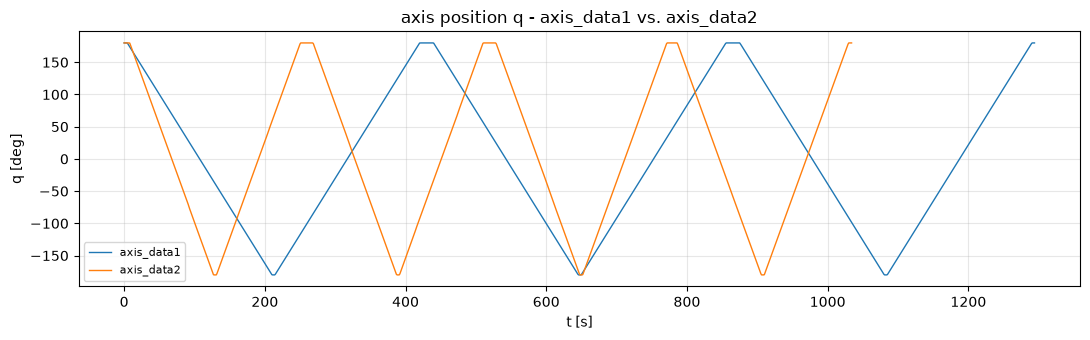

In [11]:
# The two recordings on a real time axis: same motion, different pace and length.
plt.figure(figsize=(11, 3.5))
plt.plot(a, lw=1.0, label="axis_data1")
plt.plot(b, lw=1.0, label="axis_data2")
plt.title("axis position q - axis_data1 vs. axis_data2")
plt.xlabel("t [s]")
plt.ylabel("q [deg]")
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## DTW

In [12]:
D_q = dtw_cost_matrix(a, b)
path_q = dtw_path(D_q)

print(f"cost matrix   : {D_q.shape}")
print(f"dtw distance  : {D_q[-1, -1]:,.1f} deg")
print(f"path length   : {len(path_q)} pairs")
print(f"normalised    : {D_q[-1, -1] / len(path_q):,.3f}")

cost matrix   : (1296, 1036)
dtw distance  : 25,823.8 deg
path length   : 1555 pairs
normalised    : 16.607


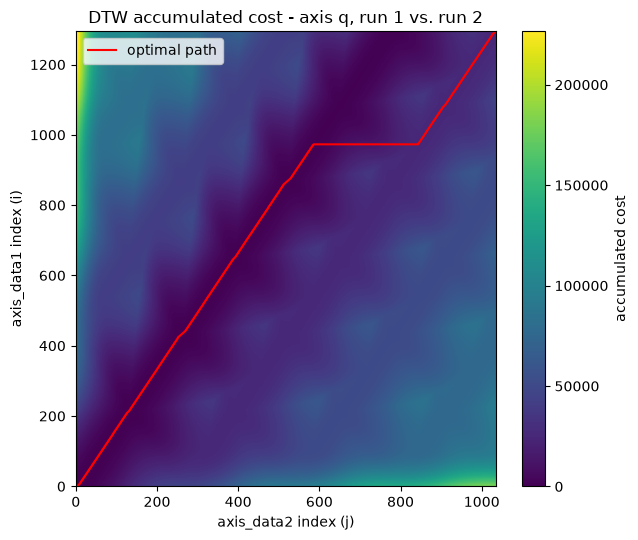

In [13]:
plotting.plot_cost_matrix(
    D_q[1:, 1:],  # drop the padding border for plotting
    path=path_q,
    title="DTW accumulated cost - axis q, run 1 vs. run 2",
    xlabel="axis_data2 index (j)",
    ylabel="axis_data1 index (i)",
)

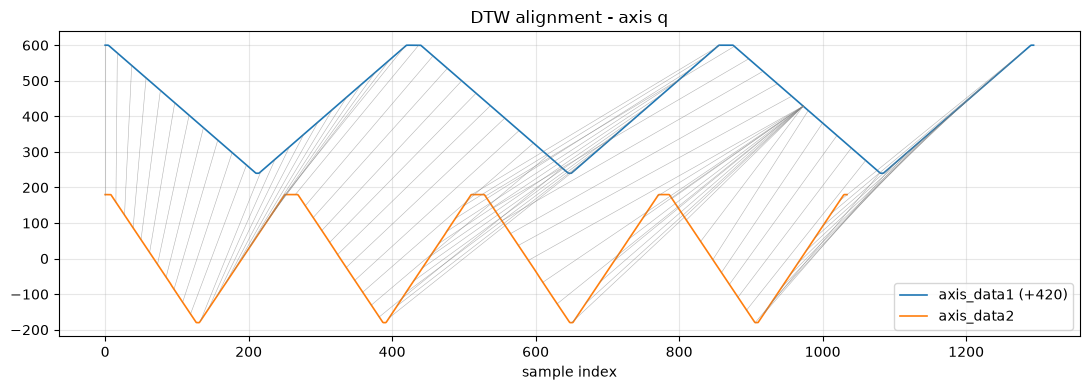

In [14]:
# The alignment on the signals themselves. The staircase in the path above shows up here
# as fans of grey lines: where one recording dwells at +180 deg, DTW matches many of its
# samples to a single sample of the other.
plotting.plot_alignment(
    a, b, path_q,
    labels=("axis_data1", "axis_data2"),
    offset=420.0, every=20,
    title="DTW alignment - axis q",
)